### Creating CSV file 

In [1]:
import pandas as pd

df = pd.read_csv("results.csv")
print(df)

  sequence    method  accuracy  reward  blocked_frames
0  factory  baseline    0.7528  1279.0             207
1  factory   adapted    0.8716  1634.0             207
2     p004  baseline    0.8901  1119.5             102
3     p004   adapted    0.9166  1160.0             102
4     p006  baseline    0.7232   418.0              18
5     p006   adapted    0.8712   580.0              18


In [2]:
baseline = df[df["method"] == "baseline"]
adapted = df[df["method"] == "adapted"]

### Figure 4.1 PPO Training Curve

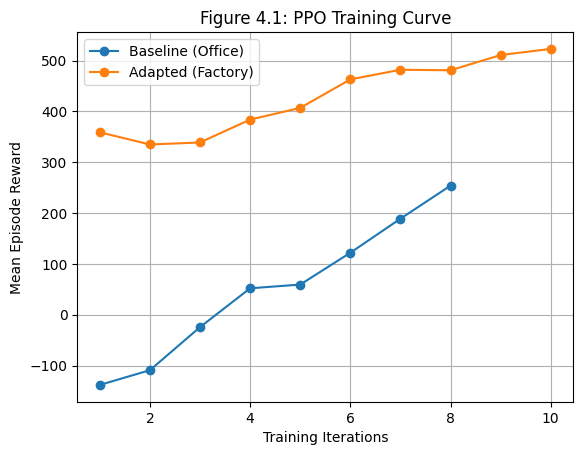

In [16]:
import matplotlib.pyplot as plt

# -----------------------
# Baseline training curve
# -----------------------
baseline_x = [1,2,3,4,5,6,7,8]
baseline_y = [-138, -109, -24.3, 52.1, 59.4, 122, 189, 254]

# -----------------------
# Adapted training curve
# -----------------------
adapted_x = [1,2,3,4,5,6,7,8,9,10]
adapted_y = [359, 335, 339, 384, 407, 463, 482, 481, 511, 523]

plt.figure()

plt.plot(baseline_x, baseline_y, marker="o", label="Baseline (Office)")
plt.plot(adapted_x, adapted_y, marker="o", label="Adapted (Factory)")

plt.title("Figure 4.1: PPO Training Curve")
plt.xlabel("Training Iterations")
plt.ylabel("Mean Episode Reward")
plt.legend()
plt.grid()

plt.savefig("figures/fig4_1_training_curve.pdf", dpi=300, bbox_inches="tight")
plt.show()

### Figure 4.2: Accuracy comparison

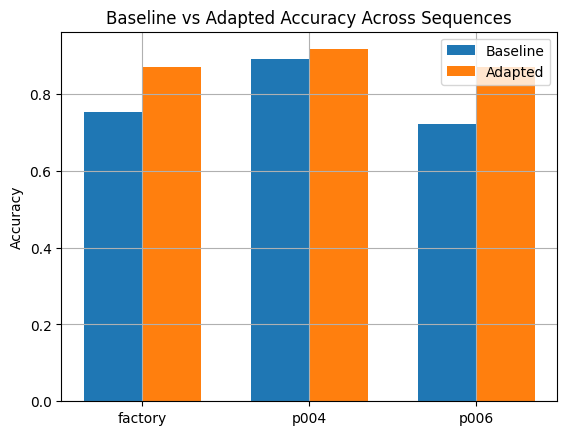

In [17]:
import matplotlib.pyplot as plt
import numpy as np

sequences = df["sequence"].unique()

baseline_acc = baseline["accuracy"].values
adapted_acc = adapted["accuracy"].values

x = np.arange(len(sequences))
width = 0.35

plt.figure()

plt.bar(x - width/2, baseline_acc, width, label="Baseline")
plt.bar(x + width/2, adapted_acc, width, label="Adapted")

plt.xticks(x, sequences)
plt.ylabel("Accuracy")
plt.title("Baseline vs Adapted Accuracy Across Sequences")
plt.legend()
plt.grid()

plt.savefig("figures/fig_4_2_accuracy_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()

### Figure 4.3: Reward Comparison

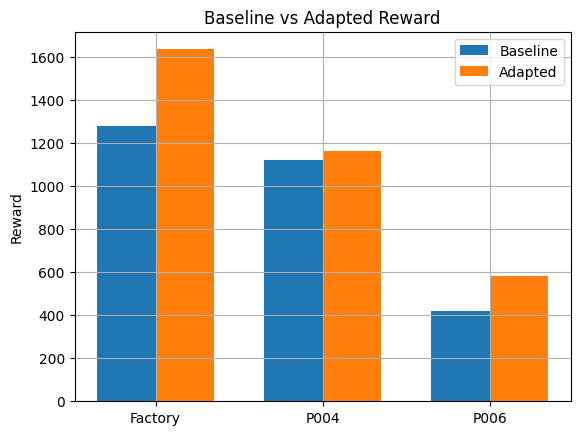

In [20]:
baseline_r = baseline["reward"].values
adapted_r = adapted["reward"].values

plt.figure()

plt.bar(x - width/2, baseline_r, width, label="Baseline")
plt.bar(x + width/2, adapted_r, width, label="Adapted")

plt.xticks(x, sequences)
plt.ylabel("Reward")
plt.title("Baseline vs Adapted Reward")
plt.legend()
plt.grid()

plt.savefig("figures/fig_4_3_reward_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()

### Figure 4.4 Cross-Environment Robustness

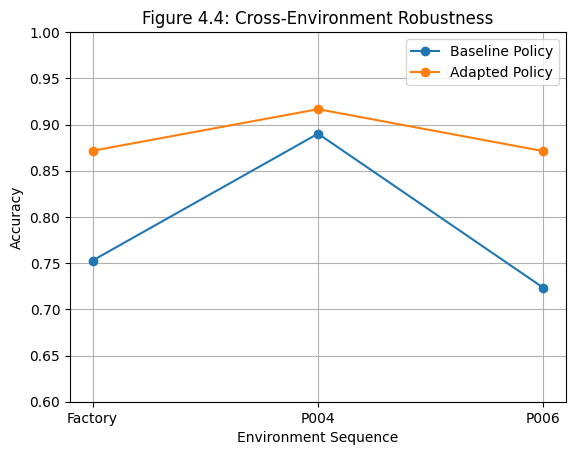

In [21]:
import matplotlib.pyplot as plt

# -------------------------
# X-axis (environments)
# -------------------------
sequences = ["Factory", "P004", "P006"]

# -------------------------
# Accuracy values
# -------------------------
baseline_acc = [0.7528, 0.8901, 0.7232]
adapted_acc  = [0.8716, 0.9166, 0.8712]

plt.figure()

plt.plot(sequences, baseline_acc, marker="o", label="Baseline Policy")
plt.plot(sequences, adapted_acc, marker="o", label="Adapted Policy")

plt.title("Figure 4.4: Cross-Environment Robustness")
plt.xlabel("Environment Sequence")
plt.ylabel("Accuracy")

plt.ylim(0.6, 1.0)  # keeps plot clean and readable

plt.grid()
plt.legend()

plt.savefig("figures/fig4_4_cross_environment_robustness.pdf", dpi=300, bbox_inches="tight")
plt.show()

### Figure 4.5: Improvement Percentage

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "sequence": ["factory","factory","p004","p004","p006","p006"],
    "method": ["baseline","adapted","baseline","adapted","baseline","adapted"],
    "accuracy": [0.7528,0.8716,0.8901,0.9166,0.7232,0.8712],
    "reward": [1279,1634,1119.5,1160,418,580],
    "blocked_frames": [207,207,102,102,18,18]
})

df.columns = df.columns.str.strip().str.lower()

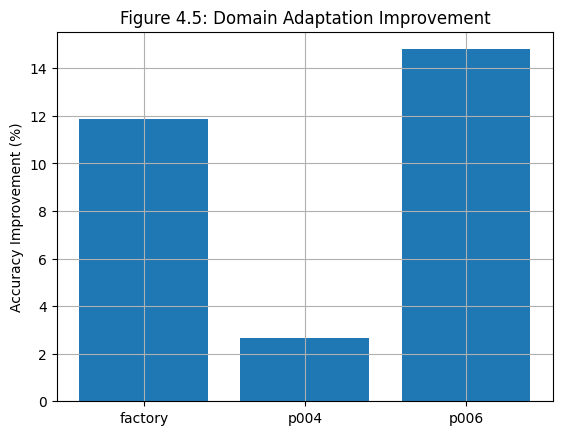

In [ ]:
pivot = df.pivot(index="sequence", columns="method", values="accuracy")

improvement = (pivot["adapted"] - pivot["baseline"]) * 100

plt.figure()
plt.bar(improvement.index, improvement.values)

plt.ylabel("Accuracy Improvement (%)")
plt.title("Figure 4.5: Domain Adaptation Improvement")
plt.grid()
plt.savefig("figures/fig4_5_improvement_percentage.pdf", dpi=300, bbox_inches="tight")
plt.show()

### Figure 4.6 Safety analysis

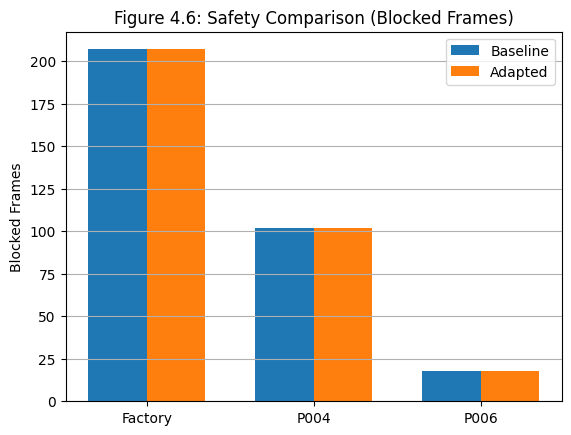

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# sequences
sequences = ["Factory", "P004", "P006"]

# blocked frames
baseline_blocks = [207, 102, 18]
adapted_blocks  = [207, 102, 18]

x = np.arange(len(sequences))
width = 0.35

plt.figure()

plt.bar(x - width/2, baseline_blocks, width, label="Baseline")
plt.bar(x + width/2, adapted_blocks, width, label="Adapted")

plt.xticks(x, sequences)
plt.ylabel("Blocked Frames")
plt.title("Figure 4.6: Safety Comparison (Blocked Frames)")
plt.legend()
plt.grid(axis="y")

plt.savefig("figures/fig4_6_safety.pdf", dpi=300, bbox_inches="tight")
plt.show()

### Figure 4.7 Heatmap

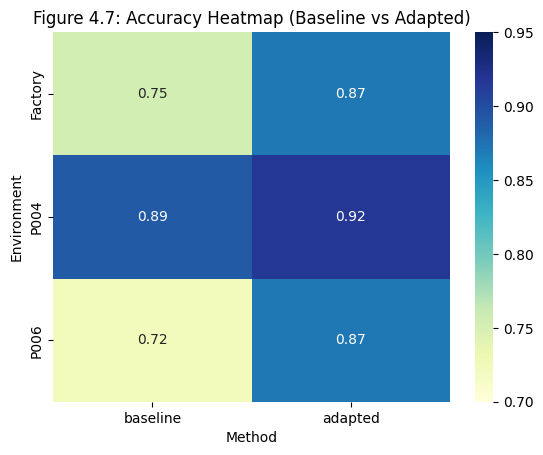

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------
# Data
# -----------------------
data = {
    "baseline": [0.7528, 0.8901, 0.7232],
    "adapted":  [0.8716, 0.9166, 0.8712]
}

sequences = ["Factory", "P004", "P006"]

df = pd.DataFrame(data, index=sequences)

plt.figure()

sns.heatmap(df, annot=True, cmap="YlGnBu", vmin=0.7, vmax=0.95)

plt.title("Figure 4.7: Accuracy Heatmap (Baseline vs Adapted)")
plt.xlabel("Method")
plt.ylabel("Environment")

plt.savefig("figures/fig4_7_heatmap.pdf", dpi=300, bbox_inches="tight")
plt.show()